# CS 229 - HW3 Extra Credit 7: Memorization or Generalization?

**Question.** Is the model reproducing training emoji, or generating genuinely novel ones? We run four
complementary experiments and tie them to the literature on memorization in generative models.

**Why this matters.** With only ~1,400 training images and a model that can comfortably overfit,
generative replication is a real risk. Detecting it requires more than eyeballing samples.

## Setup (shared with `hw3-1.ipynb`)
Imports, data, model, and the reference flow-matching functions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%matplotlib inline
import os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('mps') if torch.backends.mps.is_available() else device
print(f'Using device: {device}')
torch.manual_seed(229)

Using device: cuda


In [3]:
data = torch.load('/content/drive/My Drive/hw3_data_dedupe.pt', weights_only=False)
all_images = data['images']   # (N, 3, 32, 32) in [-1, 1]
names = data['names']

# Train/val split (fixed seed, identical to hw3-1)
torch.manual_seed(229)
perm = torch.randperm(len(all_images))
n_val = len(all_images) // 10
images = all_images[perm[n_val:]]
val_images = all_images[perm[:n_val]]
N = len(images)
print(f'Total: {len(all_images)} emoji, shape {all_images.shape}')
print(f'Train: {N}, Val: {len(val_images)}')


def show_grid(imgs, nrow=8, title=None, figsize=None):
    """Display images as a grid. imgs: (N, 3, H, W) in [-1, 1]."""
    imgs = imgs.detach().cpu().clamp(-1, 1)
    grid = make_grid((imgs + 1) / 2, nrow=nrow, padding=1, pad_value=1)
    if figsize is None:
        ncol = min(nrow, len(imgs))
        nrows = (len(imgs) + ncol - 1) // ncol
        figsize = (ncol * 1.5, nrows * 1.5 + 0.5)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    if title:
        plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

Total: 1447 emoji, shape torch.Size([1447, 3, 32, 32])
Train: 1303, Val: 144


In [4]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block (no time conditioning)."""
    def __init__(self, dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x


class EmojiViT(nn.Module):
    """Vision Transformer for emoji generation. No time conditioning."""
    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=256, depth=6, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size ** 2
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim) * 0.02)
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, patch_dim)

    def patchify(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(B, self.num_patches, -1)
        return x

    def unpatchify(self, x):
        B = x.shape[0]
        p = self.patch_size
        h = w = int(self.num_patches ** 0.5)
        x = x.reshape(B, h, w, 3, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        x = x.reshape(B, 3, h * p, w * p)
        return x

    def forward(self, x):
        x = self.patchify(x)
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.norm(x)
        x = self.head(x)
        x = self.unpatchify(x)
        return x

In [5]:
def add_noise(x, t):
    """z_t = t * x + (1 - t) * eps, eps ~ N(0, I)."""
    noise = torch.randn_like(x)
    return t * x + (1 - t) * noise


def compute_loss(model, x):
    """Weighted x-prediction loss with logit-normal time sampling."""
    B = x.shape[0]
    t = torch.sigmoid(-0.8 + 0.8 * torch.randn(B, device=x.device))
    t = t.reshape(B, 1, 1, 1)
    z_t = add_noise(x, t)
    x_hat = model(z_t)
    return torch.mean(((x_hat - x) / (1 - t)) ** 2)


@torch.no_grad()
def sample(model, num_samples, T=100, device='cpu'):
    """Euler ODE sampler for the x-prediction model."""
    model.eval()
    z = torch.randn(num_samples, 3, 32, 32, device=device)
    dt = 1.0 / T
    for k in range(T):
        t_k = k / T
        v = (model(z) - z) / (1 - t_k)
        z = z + dt * v
    return torch.clamp(z, -1, 1)

## Literature review (for the writeup)

- **Carlini et al. (2023), "Extracting Training Data from Diffusion Models"** ([arXiv:2301.13188](https://arxiv.org/abs/2301.13188)) -
  shows diffusion models can regurgitate near-exact training images; introduces membership/extraction attacks.
- **Somepalli et al. (2023), "Diffusion Art or Digital Forgery?"** ([arXiv:2212.03860](https://arxiv.org/abs/2212.03860)) -
  defines and measures *content replication* via nearest-neighbor retrieval in feature space.
- **Somepalli et al. (2023), "Understanding and Mitigating Copying"** ([arXiv:2305.20086](https://arxiv.org/abs/2305.20086)) -
  links replication to data duplication and conditioning, motivating the dedup'd dataset used here.
- **Carlini et al. (2022), "Membership Inference"** ([arXiv:2112.03570](https://arxiv.org/abs/2112.03570)) -
  framework for deciding whether a sample was in the training set.

**Method choice.** At 32x32 with no pretrained feature extractor handy, pixel-space L2 nearest-neighbor
distance is a faithful and interpretable replication signal (Somepalli's retrieval idea, simplified to raw
pixels because emoji are small, aligned, and low-variance). We pair it with diversity, a held-out
generalization test, and a noise-space interpolation smoothness check.

## Train the generator on the full training set

In [6]:
EPOCHS = 400
BATCH = 128
LR = 1e-3

torch.manual_seed(229)
model = EmojiViT().to(device)
loader = DataLoader(TensorDataset(images), batch_size=BATCH, shuffle=True)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
for ep in range(EPOCHS):
    model.train()
    for (b,) in loader:
        b = b.to(device)
        loss = compute_loss(model, b)
        opt.zero_grad(); loss.backward(); opt.step()
    if (ep + 1) % 50 == 0:
        print(f'epoch {ep+1}/{EPOCHS}  loss={loss.item():.4f}')

gen = sample(model, 64, T=100, device=device).cpu()

epoch 50/400  loss=0.2715
epoch 100/400  loss=0.2504
epoch 150/400  loss=0.2389
epoch 200/400  loss=0.1894
epoch 250/400  loss=0.1674
epoch 300/400  loss=0.3372
epoch 350/400  loss=0.1608
epoch 400/400  loss=0.1465


## Experiment 1: Nearest-neighbor replication
For each generated image, find its closest training image in pixel L2. Visual pairs plus a distance histogram against the train-set's own nearest-neighbor distances (the natural inter-emoji spacing).

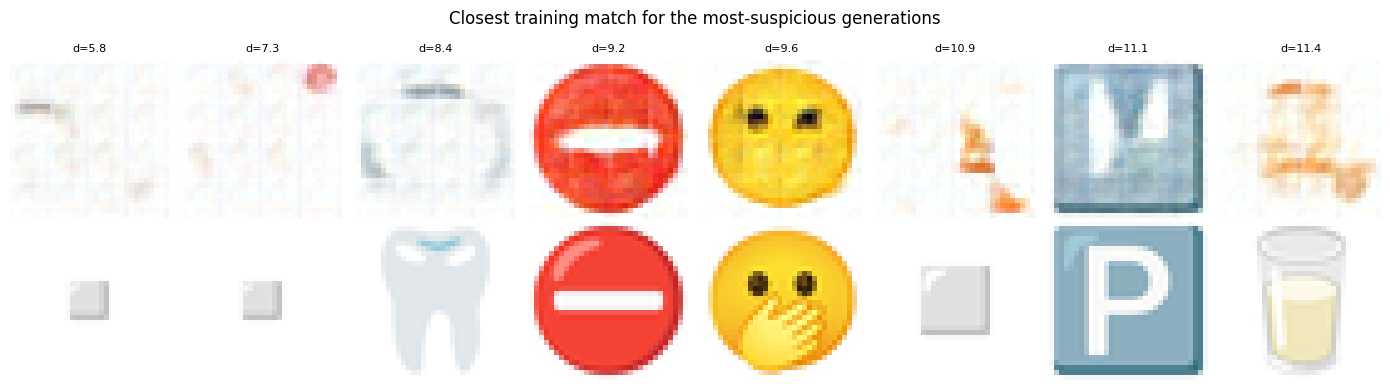

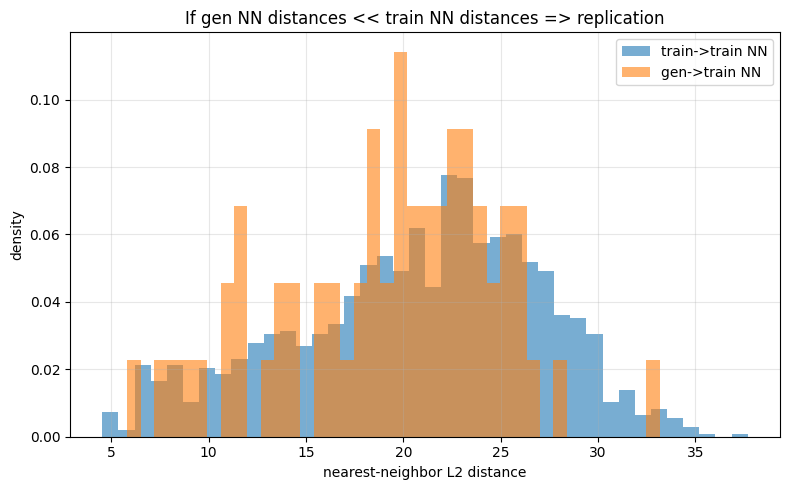

median train->train NN: 21.64
median gen->train  NN: 19.83


In [7]:
train_flat = images.reshape(len(images), -1)          # (Ntr, 3072)

def nearest(query_flat, bank_flat, exclude_self=False):
    d = torch.cdist(query_flat, bank_flat)            # (q, b)
    if exclude_self:
        d.fill_diagonal_(float('inf'))
    val, idx = d.min(dim=1)
    return val, idx

gen_flat = gen.reshape(len(gen), -1)
gen_nn_dist, gen_nn_idx = nearest(gen_flat, train_flat)
train_nn_dist, _ = nearest(train_flat, train_flat, exclude_self=True)

# Show the most-suspicious generations (smallest NN distance) next to their match
order = torch.argsort(gen_nn_dist)[:8]
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
def to_img(tn):
    return ((tn.permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)
for c, gi in enumerate(order.tolist()):
    axes[0, c].imshow(to_img(gen[gi])); axes[0, c].axis('off')
    axes[0, c].set_title(f'd={gen_nn_dist[gi]:.1f}', fontsize=8)
    axes[1, c].imshow(to_img(images[gen_nn_idx[gi]])); axes[1, c].axis('off')
axes[0, 0].set_ylabel('gen'); axes[1, 0].set_ylabel('NN train')
fig.suptitle('Closest training match for the most-suspicious generations', fontsize=12)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_nn_dist.numpy(), bins=40, alpha=0.6, density=True, label='train->train NN')
plt.hist(gen_nn_dist.numpy(), bins=40, alpha=0.6, density=True, label='gen->train NN')
plt.xlabel('nearest-neighbor L2 distance'); plt.ylabel('density')
plt.title('If gen NN distances << train NN distances => replication')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f'median train->train NN: {train_nn_dist.median():.2f}')
print(f'median gen->train  NN: {gen_nn_dist.median():.2f}')

## Experiment 2: Diversity
Pairwise distance distribution among generated images vs. among an equal-size random training subset. Collapsed (low-diversity) generation shows a left-shifted distribution.

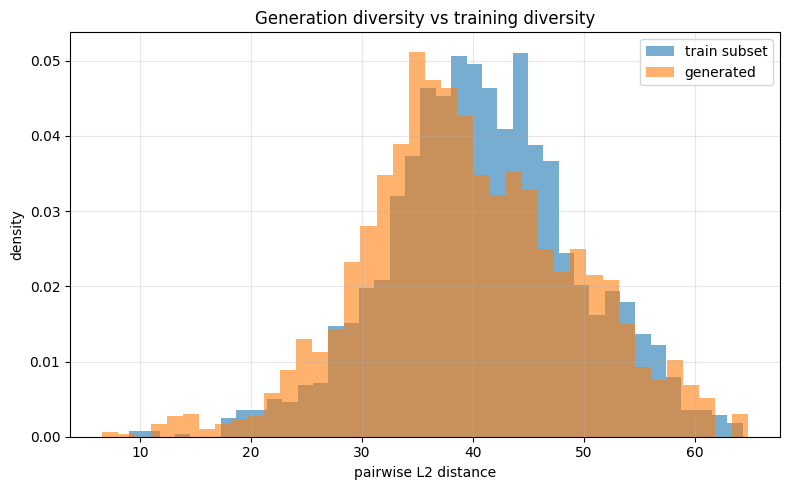

In [8]:
def pairwise_dists(flat):
    d = torch.cdist(flat, flat)
    iu = torch.triu_indices(len(flat), len(flat), offset=1)
    return d[iu[0], iu[1]]

sub = images[torch.randperm(len(images))[:len(gen)]].reshape(len(gen), -1)
plt.figure(figsize=(8, 5))
plt.hist(pairwise_dists(sub).numpy(), bins=40, alpha=0.6, density=True, label='train subset')
plt.hist(pairwise_dists(gen_flat).numpy(), bins=40, alpha=0.6, density=True, label='generated')
plt.xlabel('pairwise L2 distance'); plt.ylabel('density')
plt.title('Generation diversity vs training diversity')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Experiment 3: Held-out generalization test
Train a second model on only *half* the data. If it memorizes, its generations sit much closer to the seen half than to the held-out half. If it generalizes, the two distances are comparable.

[half] epoch 100/400  loss=0.3307
[half] epoch 200/400  loss=0.2161
[half] epoch 300/400  loss=0.1958
[half] epoch 400/400  loss=0.2402


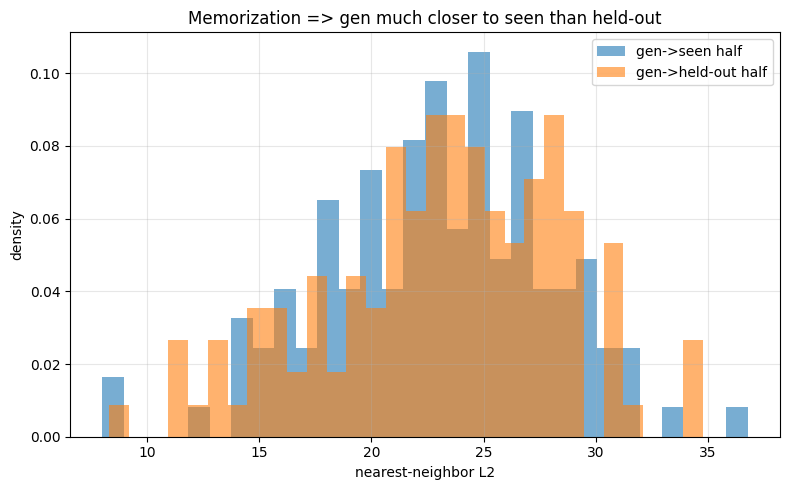

median gen->seen:     23.11
median gen->held-out: 23.48


In [9]:
half = len(images) // 2
seen = images[:half]
heldout = images[half:]

torch.manual_seed(0)
model2 = EmojiViT().to(device)
loader2 = DataLoader(TensorDataset(seen), batch_size=BATCH, shuffle=True)
opt2 = torch.optim.AdamW(model2.parameters(), lr=LR, weight_decay=0.01)
for ep in range(EPOCHS):
    model2.train()
    for (b,) in loader2:
        b = b.to(device)
        loss = compute_loss(model2, b)
        opt2.zero_grad(); loss.backward(); opt2.step()
    if (ep + 1) % 100 == 0:
        print(f'[half] epoch {ep+1}/{EPOCHS}  loss={loss.item():.4f}')

gen2 = sample(model2, 128, T=100, device=device).cpu().reshape(128, -1)
d_seen, _ = nearest(gen2, seen.reshape(len(seen), -1))
d_held, _ = nearest(gen2, heldout.reshape(len(heldout), -1))
plt.figure(figsize=(8, 5))
plt.hist(d_seen.numpy(), bins=30, alpha=0.6, density=True, label='gen->seen half')
plt.hist(d_held.numpy(), bins=30, alpha=0.6, density=True, label='gen->held-out half')
plt.xlabel('nearest-neighbor L2'); plt.ylabel('density')
plt.title('Memorization => gen much closer to seen than held-out')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
print(f'median gen->seen:     {d_seen.median():.2f}')
print(f'median gen->held-out: {d_held.median():.2f}')

## Experiment 4: Noise-space interpolation
Spherically interpolate (slerp) between two noise seeds and sample along the path. Smooth, semantically continuous morphs indicate a learned manifold rather than a lookup table of memorized points.

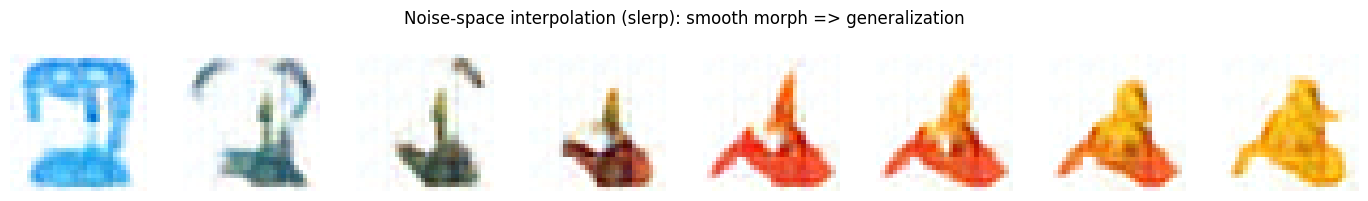

In [10]:
def slerp(a, b, ts):
    a_f, b_f = a.flatten(), b.flatten()
    omega = torch.acos((a_f @ b_f / (a_f.norm() * b_f.norm())).clamp(-1, 1))
    so = torch.sin(omega)
    out = []
    for t in ts:
        if so < 1e-6:
            out.append((1 - t) * a + t * b)
        else:
            out.append((torch.sin((1 - t) * omega) / so) * a + (torch.sin(t * omega) / so) * b)
    return torch.stack(out)

@torch.no_grad()
def sample_from(model, z, T=100):
    model.eval()
    dt = 1.0 / T
    for k in range(T):
        z = z + dt * (model(z) - z) / (1 - k / T)
    return z.clamp(-1, 1)

torch.manual_seed(3)
za = torch.randn(3, 32, 32, device=device)
zb = torch.randn(3, 32, 32, device=device)
steps = torch.linspace(0, 1, 8)
path = slerp(za, zb, steps).to(device)
morph = sample_from(model, path).cpu()
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for c in range(8):
    axes[c].imshow(((morph[c].permute(1, 2, 0).numpy() + 1) / 2).clip(0, 1)); axes[c].axis('off')
fig.suptitle('Noise-space interpolation (slerp): smooth morph => generalization', fontsize=12)
plt.tight_layout(); plt.show()

## Discussion / Conclusion

Synthesize the four signals:

1. **NN replication**: if the gen->train NN distances overlap the train->train NN distances, the model is
   not copying. A spike of near-zero distances would indicate memorized samples (inspect the pairs).
2. **Diversity**: matching pairwise-distance distributions argue against mode collapse / memorization.
3. **Held-out test**: comparable gen->seen and gen->held-out distances are the strongest evidence of
   generalization; a large gap indicates memorization of the seen half.
4. **Interpolation**: smooth morphs support a learned continuous manifold.

State your verdict for *this* model and training budget. Note the limitation that pixel-space L2 is a
coarse perceptual metric (Somepalli et al. use deep features); a natural extension is repeating
Experiment 1 with CLIP or LPIPS features.

**For the writeup:** include all four figures, the median-distance numbers printed above, and the
literature-grounded justification of the pixel-L2 choice.